In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("../dataset/cleaned_data/supply_chain_cleaned.csv")

In [3]:
df.columns

Index(['date', 'sku_id', 'warehouse_id', 'supplier_id', 'region', 'units_sold',
       'inventory_level', 'supplier_lead_time_days', 'reorder_point',
       'order_quantity', 'unit_cost', 'unit_price', 'promotion_flag',
       'stockout_flag', 'demand_forecast', 'revenue', 'cost', 'gross_profit',
       'forecast_error', 'absolute_forecast_error', 'gross_margin_pct',
       'forecast_accuracy_pct', 'inventory_gap', 'replenishment_risk',
       'inventory_coverage_days', 'year', 'month', 'month_name', 'day_of_week',
       'day_of_week_num'],
      dtype='object')

## 1. Basic Distributions

This section examines the distribution of key demand and financial variables to understand their typical values, spread, and potential skewness.

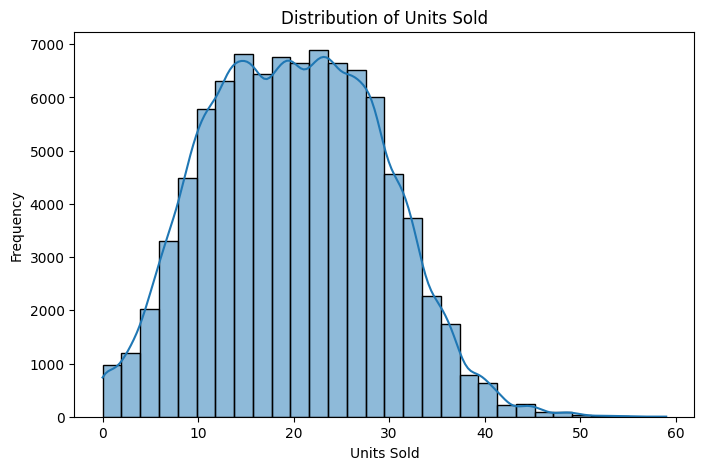

In [4]:
plt.figure(figsize=(8, 5))

sns.histplot(df["units_sold"], bins=30, kde=True)

plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

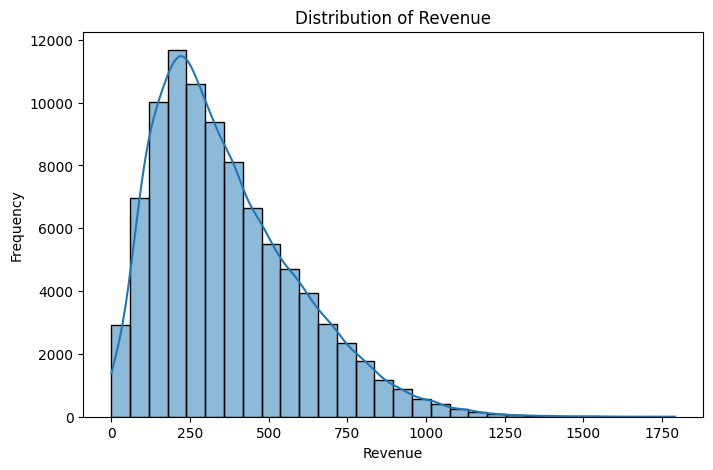

In [5]:
plt.figure(figsize=(8, 5))

sns.histplot(df["revenue"], bins=30, kde=True)

plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

In [6]:
df[["units_sold", "revenue"]].describe()

,units_sold,revenue
count,91250.000000,91250.000000
mean,20.054564,366.316024
std,9.068602,228.121990
min,0.000000,0.000000
25%,13.000000,194.220000
50%,20.000000,318.600000
75%,27.000000,498.870000
max,59.000000,1791.620000


## 2. Time Trend Analysis

This section examines monthly revenue patterns to identify changes, fluctuations, and recurring trends over the year.

In [7]:
monthly_data = df.groupby("month").agg(
    total_revenue=("revenue", "sum")
).reset_index()

monthly_data

,month,total_revenue
0,1,3224684.78
1,2,3596623.24
2,3,4232663.58
3,4,4089320.27
4,5,3851210.26
5,6,3100546.96
6,7,2470711.65
7,8,1811864.31
8,9,1385993.27
9,10,1455408.84


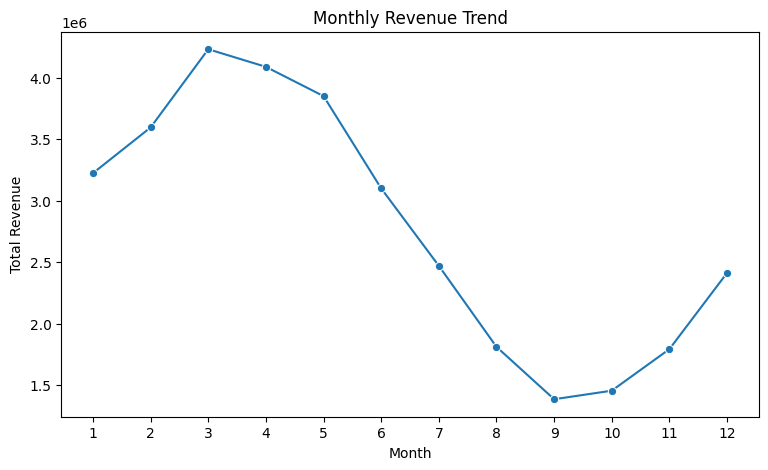

In [8]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=monthly_data,
    x="month",
    y="total_revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(range(1, 13))
plt.show()

## 3. Correlation Analysis

This section examines the linear relationships between key operational and financial variables to identify variables that move together.

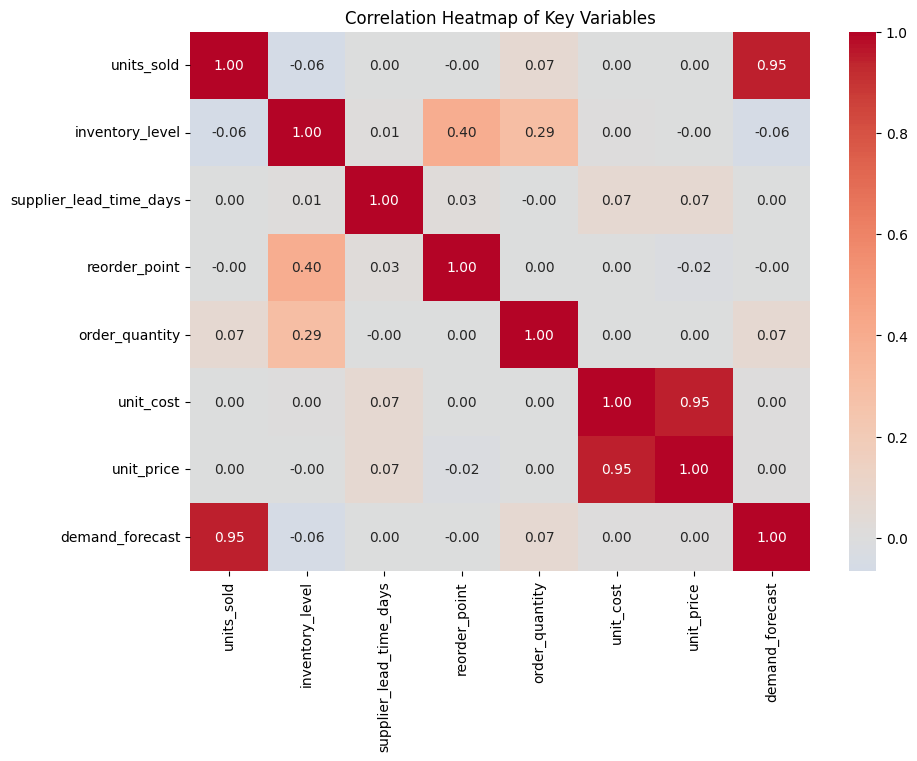

In [9]:
corr_cols = [
    "units_sold",
    "inventory_level",
    "supplier_lead_time_days",
    "reorder_point",
    "order_quantity",
    "unit_cost",
    "unit_price",
    "demand_forecast"
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Key Variables")
plt.show()

## 4. Inventory and Forecast Exploration

This section examines inventory positioning and forecast performance to identify potential replenishment and demand-planning issues.

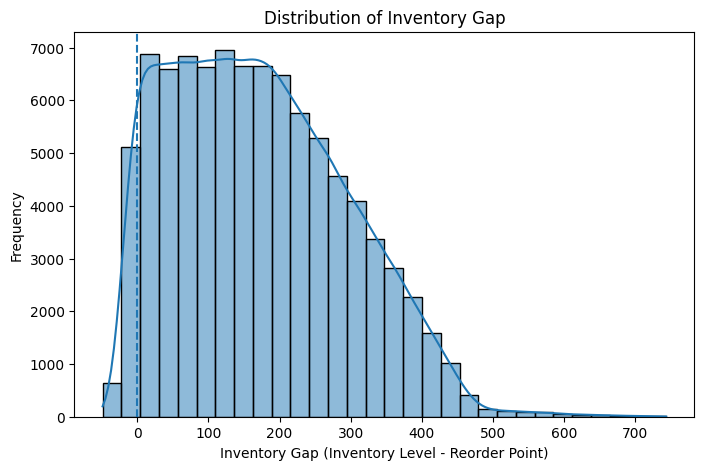

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["inventory_gap"],
    bins=30,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.title("Distribution of Inventory Gap")
plt.xlabel("Inventory Gap (Inventory Level - Reorder Point)")
plt.ylabel("Frequency")
plt.show()

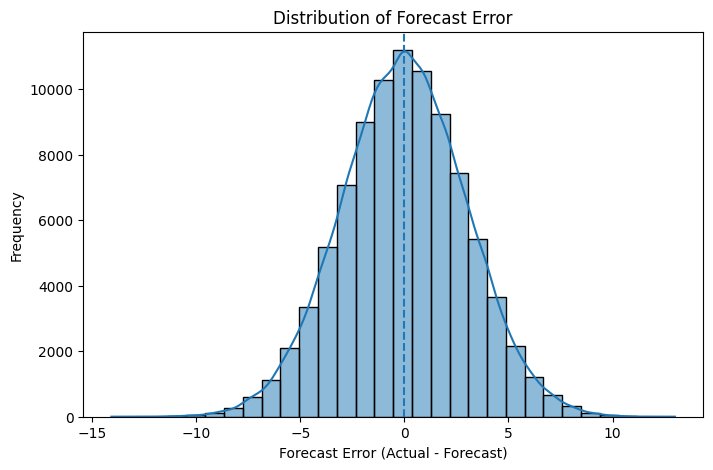

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["forecast_error"].dropna(),
    bins=30,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.title("Distribution of Forecast Error")
plt.xlabel("Forecast Error (Actual - Forecast)")
plt.ylabel("Frequency")
plt.show()

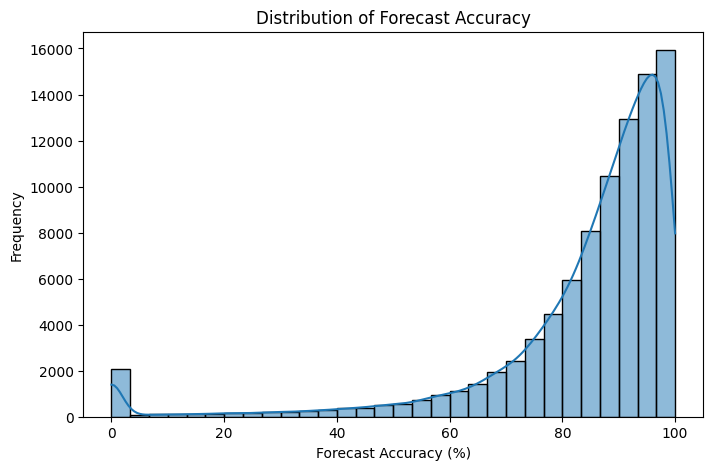

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["forecast_accuracy_pct"].dropna(),
    bins=30,
    kde=True
)

plt.title("Distribution of Forecast Accuracy")
plt.xlabel("Forecast Accuracy (%)")
plt.ylabel("Frequency")
plt.show()

## 5. Key EDA Findings

The exploratory analysis revealed the following key patterns:

- Units sold are centered around a typical daily demand level, with observations spread across a relatively wide range.
- Revenue is right-skewed, with most observations concentrated at lower revenue levels and a smaller number of high-revenue observations.
- Monthly revenue shows substantial variation throughout the year, reaching its highest level around March before declining toward September and recovering toward the end of the year.
- Inventory gap varies across observations, with some records falling below zero, indicating inventory levels below their respective reorder points.
- Forecast error includes both positive and negative values, indicating both under-forecasting and over-forecasting.
- Forecast accuracy varies across observations, suggesting that forecast performance is not uniform across the dataset.
- The correlation analysis highlights relationships among the operational variables that can be investigated further through SQL-based business analysis.